<a href="https://colab.research.google.com/github/LGLV-Ciencia-de-Datos/Curso_python_Ciencia_de_Datos/blob/main/c)_Categorical_Variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Variables categóricas**
Hay muchos datos no numéricos por ahí. Aquí tienes cómo utilizarlos en el aprendizaje automático.

En este tutorial, aprenderás qué es una variable categórica, junto con tres enfoques para manejar este tipo de datos.
# **Introducción**
Una variable categórica solo puede tomar un número limitado de valores.
* Considera una encuesta que pregunta con qué frecuencia desayunas y ofrece cuatro opciones: 'Nunca', 'Rara vez', 'La mayoría de los días' o 'Todos los días'. En este caso, los datos son categóricos, porque las respuestas se agrupan en un conjunto fijo de categorías.
* Si las personas respondieran a una encuesta sobre qué marca de coche poseen, las respuestas se clasificarían en categorías como "Honda", "Toyota' y "Ford".
En este caso, los datos también son categóricos.

Intentar introducir estas variables en la mayoría de los modelos de aprendizaje automático en Python sin preprocesarlas primero provocará un error. En este tutorial, compararemos tres enfoques que puedes usar para preparar tus datos categóricos.

### **Tres enfoque**s
1) **Eliminar variables categóricas:**
El método más sencillo para tratar con variables categóricas es simplemente eliminarlas del conjunto de datos. Este enfoque solo funcionará bien si las columnas no contenían información útil.
2) **Codificación ordinal:**
La codificación ordinal asigna a cada valor único un número entero diferente.

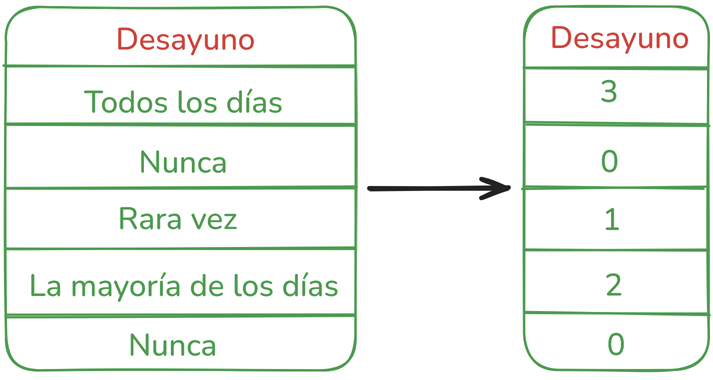

Este enfoque asume un orden en las categorías: 'Nunca' (0) < 'Rara vez' (1) < 'La mayoría de los días' (2) < 'Todos los días' (3). Esta suposición tiene sentido en este ejemplo, porque existe una clasificación indiscutible en las categorías. No todas las variables categóricas tienen un orden claro en sus valores, pero a aquellas que sí lo tienen las llamamos variables ordinales. Para los modelos basados en árboles (como los árboles de decisión y los bosques aleatorios), se puede esperar que la codificación ordinal funcione bien con variables ordinales.



3) **Codificación One-Hot:**
La codificación one-hot crea columnas nuevas que indican la presencia (o ausencia) de cada valor posible en los datos originales. Para entender esto, trabajaremos con un ejemplo.

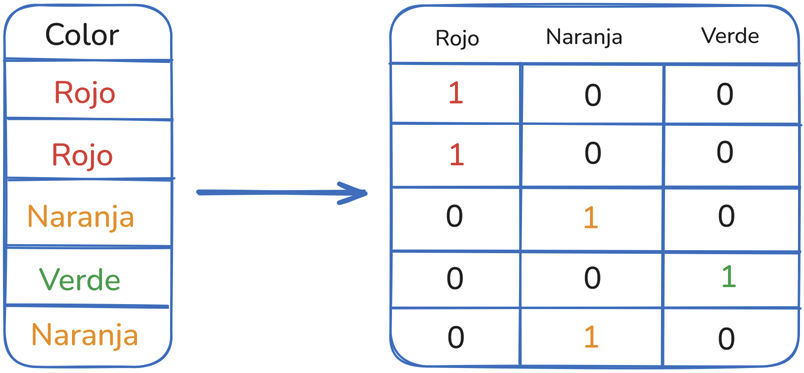

En el conjunto de datos original, "Color" es una variable categórica con tres categorías: 'Rojo', 'Naranja' y 'Verde'. La codificación one-hot correspondiente contiene una columna para cada valor posible y una fila para cada fila del conjunto de datos original. Donde el valor original era 'Rojo', colocamos un 1 en la columna 'Rojo'; si el valor original era 'Naranja', colocamos un 1 en la columna 'Naranja', y así sucesivamente.
A diferencia de la codificación ordinal, la codificación one-hot no asume un orden en las categorías. Por ello, se puede esperar que este método funcione especialmente bien cuando no exista un orden claro en los datos categóricos (por ejemplo, 'Rojo' no es ni más ni menos que 'Naranja'). Nos referimos a las variables categóricas sin un ranking intrínseco como variables nominales.
Por lo general, la codificación one-hot no funciona bien si la variable categórica tiene un gran número de valores (es decir, normalmente no se utiliza para variables con más de 15 valores diferentes).

### **Ejemplo**
Al igual que en el tutorial anterior, trabajaremos con el conjunto de datos de vivienda de Melbourne.
No nos centraremos en la fase de carga de datos. En su lugar, puedes imaginar que ya estás en un punto en el que ya tienes los datos de entrenamiento y validación en X_train, X_valid, y_train y y_valid.

In [ ]:
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

print("Path to dataset files:", path)

# Load the data into a pandas DataFrame
melbourne_file_path = path + '/melb_data.csv'
data = pd.read_csv(melbourne_file_path)

# Print the first 5 rows of the DataFrame
display(data.head(2))

In [ ]:
from sklearn.model_selection import train_test_split

# Separate target from predictors
y = data.Price
X = data.drop(['Price'], axis=1)

# Divide data into training and validation subsets
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                                random_state=0)

# Drop columns with missing values (simplest approach)
cols_with_missing = [col for col in X_train_full.columns if X_train_full[col].isnull().any()]
X_train_full.drop(cols_with_missing, axis=1, inplace=True)
X_valid_full.drop(cols_with_missing, axis=1, inplace=True)

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
low_cardinality_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and
                        X_train_full[cname].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

# Keep selected columns only
my_cols = low_cardinality_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()

Echamos un vistazo a los datos de entrenamiento con el método head() a continuación.

In [ ]:
X_train.head()

A continuación, obtenemos una lista de todas las variables categóricas en los datos de entrenamiento. Hacemos esto comprobando el tipo de dato (o dtype) de cada columna. El tipo de dato 'objeto' indica que la columna contiene texto (aunque teóricamente podría ser otra cosa, pero eso no es relevante para nuestros fines). Para este conjunto de datos, las columnas con texto indican variables categóricas.

In [ ]:
# 's' es una variable que almacena una serie booleana.
# 'X_train.dtypes' devuelve el tipo de dato para cada columna en el DataFrame 'X_train'.
# '== 'object'' compara cada tipo de dato con la cadena 'object'.
# El resultado es una serie de valores True/False, donde True indica que la columna es de tipo 'object' (categórica).
s = (X_train.dtypes == 'object')

# 'object_cols' es una lista que contendrá los nombres de las columnas categóricas.
# 's[s]' filtra la serie booleana 's' para quedarse solo con los valores que son True.
# Esto efectivamente selecciona las filas (columnas del DataFrame original) que son de tipo 'object'.
# '.index' extrae los nombres de las columnas de la serie filtrada.
# 'list(...)' convierte ese índice en una lista.
object_cols = list(s[s].index)

# Esta línea imprime un encabezado para la salida.
print("Categorical variables:")
# Esta línea imprime la lista de nombres de columnas que se identificaron como categóricas.
print(object_cols)

### **Definir la función para medir la calidad de cada enfoque**

Definimos una función llamada score_dataset() para comparar los tres enfoques diferentes para tratar variables categóricas. Esta función informa del error absoluto medio (MAE) obtenido con un modelo de bosque aleatorio. En general, queremos que el MAE sea lo más bajo posible!

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Function for comparing different approaches
def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

### **Puntuación del Enfoque 1** (Eliminar variables categóricas)
Eliminamos las columnas de objetos con el método select_dtypes().

In [ ]:
drop_X_train = X_train.select_dtypes(exclude=['object'])
drop_X_valid = X_valid.select_dtypes(exclude=['object'])

print("MAE from Approach 1 (Drop categorical variables):")
print(score_dataset(drop_X_train, drop_X_valid, y_train, y_valid))

### **Puntuación del Enfoque 2** (Codificación ordinal)
Scikit-learn cuenta con una clase llamada `OrdinalEncoder` que puede usarse para obtener codificaciones ordinales. Recorremos las variables categóricas y aplicamos el codificador ordinal de forma separada a cada columna.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Make copy to avoid changing original data
label_X_train = X_train.copy()
label_X_valid = X_valid.copy()

# Apply ordinal encoder to each column with categorical data
ordinal_encoder = OrdinalEncoder()
label_X_train[object_cols] = ordinal_encoder.fit_transform(X_train[object_cols])
label_X_valid[object_cols] = ordinal_encoder.transform(X_valid[object_cols])

print("MAE from Approach 2 (Ordinal Encoding):")
print(score_dataset(label_X_train, label_X_valid, y_train, y_valid))

En la celda de código de arriba, para cada columna, asignamos aleatoriamente cada valor único a un número entero diferente. Este es un enfoque común que es más sencillo que proporcionar etiquetas personalizadas; sin embargo, podemos esperar una mejora adicional en el rendimiento si proporcionamos etiquetas mejor informadas para todas las variables ordinales.

### **Puntuación del enfoque 3** (Codificación One-Hot)¶
Utilizamos la clase `OneHotEncoder` de scikit-learn para obtener codificaciones one-hot. Hay varios parámetros que se pueden usar para personalizar su comportamiento.
* Establecemos handle_unknown='ignore' para evitar errores cuando los datos de validación contienen clases que no están representadas en los datos de entrenamiento, y
* al configurar sparse=False, aseguramos que las columnas codificadas se devuelvan como un array de numpy (en lugar de una matriz dispersa).

Para usar el codificador, proporcionamos únicamente las columnas categóricas que queremos codificar en modo one-hot. Por ejemplo, para codificar los datos de entrenamiento, suministramos `X_train[object_cols]`. (object_cols en la celda de código siguiente es una lista con los nombres de las columnas que contienen datos categóricos, por lo que `X_train[object_cols]` contiene todos los datos categóricos del conjunto de entrenamiento).

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Apply one-hot encoder to each column with categorical data
OH_encoder = OneHotEncoder(handle_unknown='ignore')
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train[object_cols]).toarray())
OH_cols_valid = pd.DataFrame(OH_encoder.transform(X_valid[object_cols]).toarray())

# One-hot encoding removed index; put it back
OH_cols_train.index = X_train.index
OH_cols_valid.index = X_valid.index

# Remove categorical columns (will replace with one-hot encoding)
num_X_train = X_train.drop(object_cols, axis=1)
num_X_valid = X_valid.drop(object_cols, axis=1)

# Add one-hot encoded columns to numerical features
OH_X_train = pd.concat([num_X_train, OH_cols_train], axis=1)
OH_X_valid = pd.concat([num_X_valid, OH_cols_valid], axis=1)

# Ensure all columns have string type
OH_X_train.columns = OH_X_train.columns.astype(str)
OH_X_valid.columns = OH_X_valid.columns.astype(str)

print("MAE from Approach 3 (One-Hot Encoding):")
print(score_dataset(OH_X_train, OH_X_valid, y_train, y_valid))

### **¿Cuál es el mejor enfoque?**

En este caso, eliminar las columnas categóricas (Enfoque 1) fue el peor, ya que obtuvo la puntuación MAE más alta. En cuanto a los otros dos enfoques, dado que las puntuaciones MAE devueltas son muy similares en valor, no parece haber ningún beneficio significativo en uno u otro.

En general, la codificación one-hot (Enfoque 3) suele ser la que mejor funciona, y eliminar las columnas categóricas (Enfoque 1) suele ser la peor, aunque esto varía según cada caso.

### **Conclusión**

El mundo está lleno de datos categóricos. ¡Serás mucho más eficaz como científico de datos si sabes cómo usar este tipo de datos tan común!